# Reto Parcial 1: Clasificación de Movimientos de Rehabilitación (REHAB)
## Etapa de Selección, Configuración, Entrenamiento y Comparación de Modelos

**Equipo de Desarrollo:** Angel David Lugo, José Pablo, Juan Pablo  
**Curso:** Inteligencia Artificial Avanzada para Ciencia de Datos  
**Institución:** Tecnológico de Monterrey  
**Fecha:** Septiembre 2026  

---

### Resumen Ejecutivo
Este documento técnico y experimental aborda la problemática de clasificar de forma automatizada 15 ejercicios estandarizados de rehabilitación motora en pacientes con secuelas de Accidente Cerebrovascular (ACV), a partir de mediciones cinemáticas multicanal (sensores inerciales IMU y guante sensorial de flexión).

A lo largo de este notebook se desarrollan, configuran, entrenan y comparan rigurosamente **múltiples modelos y familias de algoritmos clásicos de Machine Learning** (Regresión Logística, K-Nearest Neighbors, Árboles de Decisión, Support Vector Machines y Random Forest), evaluando distintas configuraciones de hiperparámetros y justificando cada decisión metodológica, matemática y biomecánica.


---
## 1. Análisis del Propósito e Ideas del Repositorio

### 1.1 Propósito Clínico y Tecnológico
En la terapia física post-ACV, la monitorización continua y la evaluación cuantitativa de los ejercicios de rehabilitación son esenciales para medir la recuperación neuroplástica y evitar compensaciones motoras perjudiciales. Los métodos tradicionales requieren supervisión presencial constante por parte de fisioterapeutas, lo que limita la frecuencia y accesibilidad de las sesiones. 

El repositorio implementa un sistema inteligente basado en el dataset **REHAB** (*Lv et al., 2026, Nature Scientific Data*), recolectado de **120 pacientes post-ACV** que utilizaron:
1. **Dos sensores inerciales (IMUs)** colocados en antebrazo y brazo (canales de orientación tridimensional: Pitch, Yaw, Roll).
2. **Un guante sensorial con sensores de flexión** en cada uno de los 5 dedos (Pulgar, Índice, Medio, Anular, Meñique) más el canal de inclinación de la muñeca (Glove Pitch).

### 1.2 Formulación Matemática del Problema
El reto consiste en resolver un problema de **Clasificación Supervisada Multiclase**:
$$\mathcal{X} \subset \mathbb{R}^{D} \longrightarrow \mathcal{Y} = \{0, 1, 2, \dots, K-1\}$$
donde cada muestra representa la ejecución temporal de una repetición de ejercicio y $\mathcal{Y}$ corresponde al movimiento funcional ejecutado.

### 1.3 Naturaleza de los Datos: Del Dominio Temporal al Espacio Tabular
Las señales cinemáticas originales tienen una longitud de $T = 880$ puntos temporales a lo largo de $C = 12$ canales ($880 \times 12 = 10,560$ puntos por repetición). Entrenar clasificadores clásicos directamente sobre la señal cruda aplanada introduce la "maldición de la dimensionalidad", alta correlación temporal y riesgo severo de sobreajuste.

Por ello, el pipeline realiza una **Extracción de Descriptores Estadísticos (Feature Engineering)** calculando 5 estadísticos fundamentales por cada canal:
$$\text{Estadísticos} = \{\mu \text{ (Media)}, \sigma \text{ (Desv. Estándar)}, \min \text{ (Mínimo)}, \max \text{ (Máximo)}, \text{RMS} \text{ (Root Mean Square)}\}$$
Resultando en un espacio de características tabular continuo y denso de dimensión $D = 12 \times 5 = 60$ características por muestra.

### 1.4 Manejo del Movimiento 14 (Corrupción de Origen)
El archivo `014_1.npy` se encuentra dañado en el repositorio original de *Science Data Bank* (archivo incompleto a nivel de descarga). Para evitar sesgos artificiales por imputación en 6 de los 12 canales, el equipo optó por excluir el movimiento 14, preservando $K = 15$ clases de alta fidelidad con señales completas.


---
## 2. Configuración del Entorno y Carga de Datos

Importamos las librerías del ecosistema de ciencia de datos en Python (`scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`) y fijamos las semillas aleatorias para garantizar reproducibilidad exacta.


In [1]:
import sys
import os
import time
from pathlib import Path

# Ajustar rutas al proyecto
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn: Preprocesamiento y Validación
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Scikit-learn: Familias de Modelos Clásicos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Configuración visual
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


### 2.1 Carga del Dataset Tabular de Características
Cargamos el archivo `data/rehab_features_dataset.csv` generado a partir de las señales cinemáticas de los 12 canales.


In [2]:
csv_path = PROJECT_ROOT / "data" / "rehab_features_dataset.csv"
df = pd.read_csv(csv_path)

print(f"Dimensiones del dataset: {df.shape[0]} filas (muestras) x {df.shape[1]} columnas")
print(f"Total de valores nulos o NaN: {df.isnull().sum().sum()}")
df.head(5)


Dimensiones del dataset: 4257 filas (muestras) x 62 columnas
Total de valores nulos o NaN: 0


,IMU1_Pitch_media,IMU1_Pitch_std,IMU1_Pitch_min,IMU1_Pitch_max,IMU1_Pitch_rms,IMU1_Yaw_media,IMU1_Yaw_std,IMU1_Yaw_min,IMU1_Yaw_max,IMU1_Yaw_rms,...,Glove_Pinky_min,Glove_Pinky_max,Glove_Pinky_rms,Glove_Pitch_media,Glove_Pitch_std,Glove_Pitch_min,Glove_Pitch_max,Glove_Pitch_rms,movimiento_id,movimiento_nombre
0,-17.436447,35.016774,-69.400,38.324,39.117823,-8.991587,11.102040,-33.493,15.430,14.286495,...,17.0,32.0,25.077290,23.818526,78.476172,-71.803071,144.104615,82.011168,0,bobath handshake
1,-19.588195,35.696969,-70.209,41.602,40.718190,-10.116394,11.358083,-33.493,15.650,15.210111,...,17.0,30.0,24.698891,26.183351,79.435102,-67.832473,144.104615,83.639125,0,bobath handshake
2,-18.803524,35.995854,-70.209,41.602,40.611255,-9.126543,11.268766,-33.493,15.650,14.500996,...,17.0,31.0,24.169501,25.045099,78.043942,-59.931385,144.104615,81.964101,0,bobath handshake
3,1.934419,30.628132,-56.344,72.508,30.689159,15.645458,24.172718,-46.493,73.076,28.794108,...,21.0,42.0,27.260215,13.319856,94.916031,-168.804826,174.734939,95.846083,0,bobath handshake
4,4.005519,30.619576,-56.344,72.508,30.880457,15.685806,25.182979,-46.493,74.967,29.668619,...,21.0,42.0,26.876908,16.023364,95.229790,-168.804826,179.668105,96.568427,0,bobath handshake


### 2.2 Distribución de Clases (Movimientos Funcionales)
Examinamos la frecuencia de cada ejercicio funcional para diagnosticar el balance de las clases.


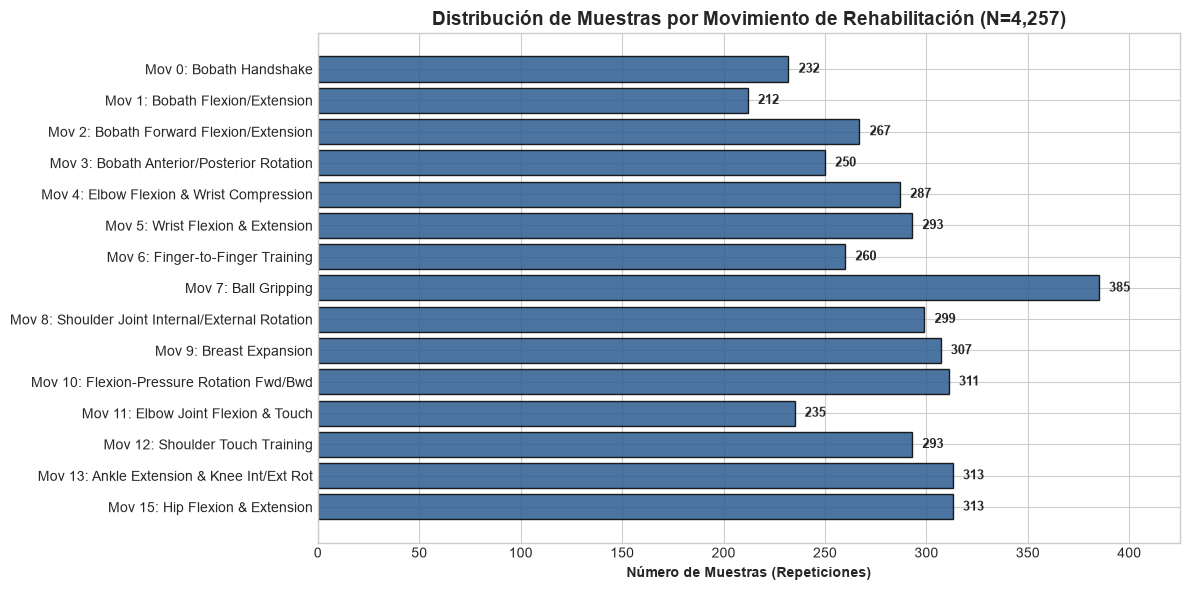

Clase con menor número de muestras: Movimiento 1 (212 muestras)
Clase con mayor número de muestras: Movimiento 7 (385 muestras)
Razón de desbalance: 1.82:1


In [3]:
# Diccionario clínico de movimientos
MOVEMENT_NAMES = {
    0: "Bobath Handshake",
    1: "Bobath Flexion/Extension",
    2: "Bobath Forward Flexion/Extension",
    3: "Bobath Anterior/Posterior Rotation",
    4: "Elbow Flexion & Wrist Compression",
    5: "Wrist Flexion & Extension",
    6: "Finger-to-Finger Training",
    7: "Ball Gripping",
    8: "Shoulder Joint Internal/External Rotation",
    9: "Breast Expansion",
    10: "Flexion-Pressure Rotation Fwd/Bwd",
    11: "Elbow Joint Flexion & Touch",
    12: "Shoulder Touch Training",
    13: "Ankle Extension & Knee Int/Ext Rot",
    15: "Hip Flexion & Extension",
}

class_counts = df["movimiento_id"].value_counts().sort_index()
class_names = [f"Mov {cid}: {MOVEMENT_NAMES.get(cid, 'Desconocido')}" for cid in class_counts.index]

plt.figure(figsize=(12, 6))
bars = plt.barh(class_names, class_counts.values, color="#2b5c8f", edgecolor="black", alpha=0.85)
plt.xlabel("Número de Muestras (Repeticiones)", fontweight="bold")
plt.title("Distribución de Muestras por Movimiento de Rehabilitación (N=4,257)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()

for bar in bars:
    w = bar.get_width()
    plt.text(w + 5, bar.get_y() + bar.get_height()/2, f"{int(w)}", va="center", fontsize=9, fontweight="bold")

plt.xlim(0, max(class_counts.values) + 40)
plt.tight_layout()
plt.show()

print(f"Clase con menor número de muestras: Movimiento {class_counts.idxmin()} ({class_counts.min()} muestras)")
print(f"Clase con mayor número de muestras: Movimiento {class_counts.idxmax()} ({class_counts.max()} muestras)")
print(f"Razón de desbalance: {class_counts.max() / class_counts.min():.2f}:1")


---
## 3. Identificación del Tipo de Datos y Estrategia de Preprocesamiento

### 3.1 Diagnóstico de Características
- **Tipo de Variables Predictoras ($X$):** 60 variables numéricas continuas sin valores faltantes.
- **Diferencias de Escala:** Las señales de orientación de las IMUs (ángulos de inclinación en grados) oscilan en rangos como $[-180^\circ, 180^\circ]$, mientras que las lecturas de flexión del guante corresponden a voltajes/resistencias analógicas de flexión. Por ende, los algoritmos basados en distancias euclidianas (KNN), márgenes de separación (SVM) o descensos de gradiente regularizados (Regresión Logística) se verían fuertemente sesgados si no se estandarizan las variables.
- **Tipo de Variable Objetivo ($y$):** Categórica discreta multiclase ($15$ clases).

### 3.2 Decisiones Metodológicas:
1. **Partición Estratificada (Train/Test Split):** Se aplica una división 80% entrenamiento (3,405 muestras) y 20% prueba (852 muestras), fijando `stratify=y` y `random_state=42`. La estratificación garantiza que la distribución porcentual de cada movimiento sea idéntica en ambos subconjuntos.
2. **Estandarización Z-Score (`StandardScaler`):**
   $$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$
   **Regla Crítica de Data Leakage:** La media $\mu$ y desviación $\sigma$ se aprenden **exclusivamente con el conjunto de entrenamiento** (`fit_transform`) y luego se aplican sin reajustar sobre el conjunto de prueba (`transform`).
3. **Métrica Principal de Decisión (Macro F1-Score):**
   $$\text{Macro F1} = \frac{1}{K} \sum_{k=1}^{K} F1_k$$
   A diferencia del Accuracy tradicional, el Macro F1 promedia el desempeño clase por clase con igual peso, impidiendo que clases con mayor número de muestras (como el movimiento 7 con 385 muestras) oculten fallas en clases menos frecuentes (como el movimiento 1 con 212 muestras).


In [4]:
# Separar características (X) y etiquetas (y)
feature_cols = [c for c in df.columns if c not in ["movimiento_id", "movimiento_nombre"]]
X = df[feature_cols].values
y = df["movimiento_id"].values

print(f"Matriz de características X: {X.shape}")
print(f"Vector de etiquetas y: {y.shape}")

# Partición estratificada 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Estandarización sin fuga de datos (Data Leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Conjunto de entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"Conjunto de prueba (Test):          {X_test.shape[0]} muestras")


Matriz de características X: (4257, 60)
Vector de etiquetas y: (4257,)
Conjunto de entrenamiento (Train): 3405 muestras
Conjunto de prueba (Test):          852 muestras


### 3.3 Visualización del Escalamiento Z-Score
Comprobamos cómo la estandarización centra las distribuciones en media 0 y varianza unitaria, nivelando la influencia de todos los canales sensoriales.


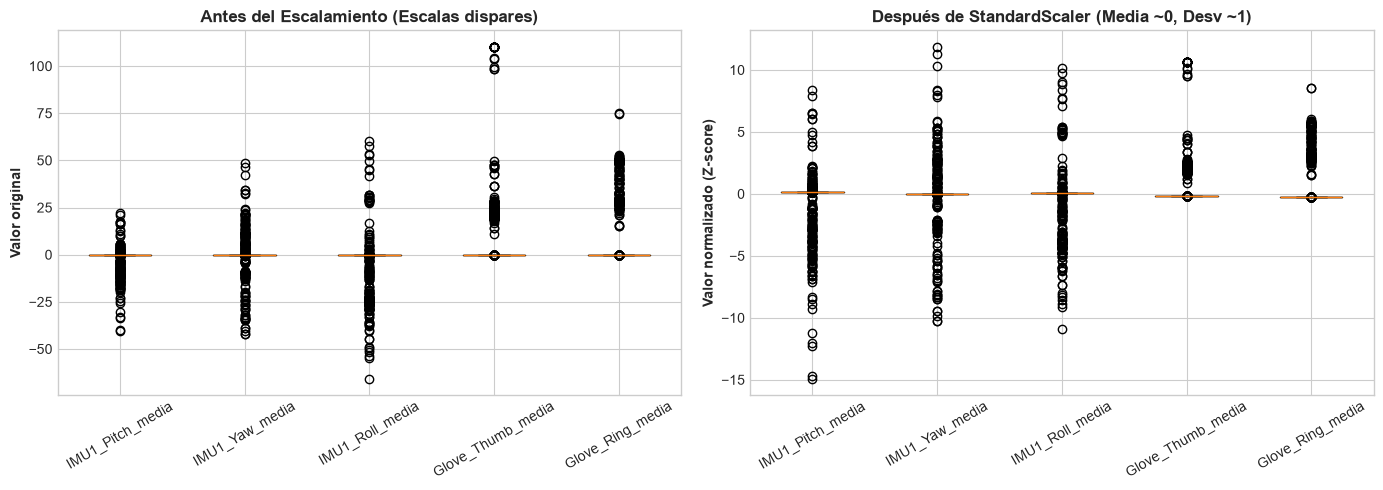

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes del escalamiento (5 variables arbitrarias)
sample_indices = [0, 5, 10, 30, 45]
sample_names = [feature_cols[i] for i in sample_indices]

axes[0].boxplot([X_train_raw[:, i] for i in sample_indices], tick_labels=sample_names)
axes[0].set_title("Antes del Escalamiento (Escalas dispares)", fontweight="bold")
axes[0].set_ylabel("Valor original", fontweight="bold")
axes[0].tick_params(axis='x', rotation=30)

# Después del escalamiento
axes[1].boxplot([X_train[:, i] for i in sample_indices], tick_labels=sample_names)
axes[1].set_title("Después de StandardScaler (Media ~0, Desv ~1)", fontweight="bold")
axes[1].set_ylabel("Valor normalizado (Z-score)", fontweight="bold")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


---
## 4. Modelos Investigados y Compatibilidad con los Datos

Para resolver este reto con métodos fundamentados y sencillos del análisis de datos, se seleccionaron 6 familias representativas de algoritmos de clasificación supervisada:

| Familia de Modelo | Algoritmo | Mecanismo Teórico | Compatibilidad con REHAB |
|---|---|---|---|
| **Lineal** | Regresión Logística Multinomial | Clasificador lineal probabilístico vía Softmax y penalización L2. | Compatible. Sirve como línea base (*baseline*) para verificar si las clases son linealmente separables en $\mathbb{R}^{60}$. |
| **Basado en Instancias** | K-Nearest Neighbors (KNN) | Clasificación por voto mayoritario entre los $k$ vecinos más cercanos en distancia euclidiana. | Muy compatible tras estandarización. No asume distribuciones de probabilidad paramétricas. |
| **Árboles Individuales** | Árbol de Decisión (CART) | Particiones recursivas ortogonales maximizando la ganancia de información (Gini / Entropía). | Altamente interpretable; insensible a monotonía de escala, pero propenso al sobreajuste si no se poda la profundidad. |
| **Ensambles (Bagging)** | Random Forest | Agregación de múltiples árboles entrenados sobre subconjuntos bootstrap de muestras y características (*Feature Bagging*). | **Ideal**. Reduce drásticamente la varianza del árbol individual, maneja relaciones no lineales complejas y correlaciones entre canales IMU. |
| **Márgenes de Soporte** | SVM con Kernel RBF | Maximización del margen geométrico proyectando el espacio a dimensión infinita con función de base radial. | Excelente para datos tabulares densos continuos y dimensionalidad moderada ($D=60$). |
| **Probabilístico Generativo** | Gaussian Naive Bayes | Suposición de independencia condicional entre características dado el movimiento con verosimilitud gaussiana. | Baseline probabilístico ultrarrápido; útil para contrastar el efecto de las correlaciones entre canales. |


---
## 5. Fase 1: Entrenamiento y Comparación de Familias de Modelos

Evaluamos los modelos mediante **Validación Cruzada Estratificada de 5 Pliegues (5-Fold Stratified CV)** sobre el conjunto de entrenamiento para medir la estabilidad y varianza del desempeño, seguido de una evaluación final en el conjunto de prueba independiente (`Test`).


In [6]:
# Definición de modelos base
modelos_base = {
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Árbol de Decisión (prof=12)": DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE),
    "SVM (Kernel RBF, C=10)": SVC(C=10.0, kernel="rbf", random_state=RANDOM_STATE),
    "Random Forest (300 árboles)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
}

# Validación cruzada estratificada de 5 pliegues
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

cv_resultados = []

print("=== Ejecutando Validación Cruzada 5-Fold sobre Train ===")
for nombre, modelo in modelos_base.items():
    t0 = time.time()
    scores = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    tiempo_cv = time.time() - t0
    
    acc_mean, acc_std = scores["test_accuracy"].mean(), scores["test_accuracy"].std()
    f1_mean, f1_std = scores["test_f1_macro"].mean(), scores["test_f1_macro"].std()
    
    cv_resultados.append({
        "Modelo": nombre,
        "CV Accuracy": f"{acc_mean:.4f} ± {acc_std:.4f}",
        "CV Macro F1": f"{f1_mean:.4f} ± {f1_std:.4f}",
        "CV Macro F1 (num)": f1_mean,
        "Tiempo CV (s)": round(tiempo_cv, 2)
    })
    print(f"{nombre:28s} | CV Macro F1: {f1_mean:.3f} ± {f1_std:.3f} | ({tiempo_cv:.1f}s)")

df_cv = pd.DataFrame(cv_resultados).sort_values("CV Macro F1 (num)", ascending=False)
df_cv.drop(columns=["CV Macro F1 (num)"])


=== Ejecutando Validación Cruzada 5-Fold sobre Train ===


Regresión Logística          | CV Macro F1: 0.828 ± 0.018 | (1.7s)


Gaussian Naive Bayes         | CV Macro F1: 0.696 ± 0.028 | (1.1s)


KNN (k=5)                    | CV Macro F1: 0.834 ± 0.021 | (1.2s)


Árbol de Decisión (prof=12)  | CV Macro F1: 0.842 ± 0.010 | (0.4s)


SVM (Kernel RBF, C=10)       | CV Macro F1: 0.937 ± 0.007 | (0.3s)


Random Forest (300 árboles)  | CV Macro F1: 0.949 ± 0.008 | (2.3s)


,Modelo,CV Accuracy,CV Macro F1,Tiempo CV (s)
5,Random Forest (300 árboles),0.9504 ± 0.0081,0.9494 ± 0.0084,2.27
4,"SVM (Kernel RBF, C=10)",0.9395 ± 0.0066,0.9374 ± 0.0070,0.34
3,Árbol de Decisión (prof=12),0.8449 ± 0.0097,0.8420 ± 0.0098,0.37
2,KNN (k=5),0.8361 ± 0.0207,0.8342 ± 0.0210,1.17
0,Regresión Logística,0.8314 ± 0.0159,0.8277 ± 0.0179,1.72
1,Gaussian Naive Bayes,0.7057 ± 0.0261,0.6955 ± 0.0281,1.13


### 5.2 Evaluación Final en el Conjunto de Prueba (Test Set)
Entrenamos cada modelo sobre la totalidad de `X_train` y evaluamos su capacidad de generalización sobre las 852 muestras no vistas de `X_test`.


In [7]:
test_resultados = []
modelos_entrenados = {}

print("=== Entrenamiento en Train y Evaluación en Test ===")
for nombre, modelo in modelos_base.items():
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t_train = time.time() - t0
    
    t0_inf = time.time()
    preds = modelo.predict(X_test)
    t_inf = time.time() - t0_inf
    
    acc = accuracy_score(y_test, preds)
    f1_mac = f1_score(y_test, preds, average="macro")
    f1_wei = f1_score(y_test, preds, average="weighted")
    
    test_resultados.append({
        "Modelo": nombre,
        "Exactitud (Test)": round(acc, 4),
        "F1 Macro (Test)": round(f1_mac, 4),
        "F1 Weighted (Test)": round(f1_wei, 4),
        "Tiempo Train (s)": round(t_train, 3),
        "Tiempo Inferencia (ms)": round(t_inf * 1000, 2)
    })
    modelos_entrenados[nombre] = modelo
    print(f"{nombre:28s} | Test Acc: {acc:.3f} | Test F1 Macro: {f1_mac:.3f} | ({t_train:.2f}s)")

df_comparacion = pd.DataFrame(test_resultados).sort_values("F1 Macro (Test)", ascending=False).reset_index(drop=True)
df_comparacion


=== Entrenamiento en Train y Evaluación en Test ===
Regresión Logística          | Test Acc: 0.826 | Test F1 Macro: 0.824 | (0.08s)
Gaussian Naive Bayes         | Test Acc: 0.717 | Test F1 Macro: 0.708 | (0.00s)
KNN (k=5)                    | Test Acc: 0.872 | Test F1 Macro: 0.871 | (0.00s)


Árbol de Decisión (prof=12)  | Test Acc: 0.876 | Test F1 Macro: 0.873 | (0.12s)


SVM (Kernel RBF, C=10)       | Test Acc: 0.953 | Test F1 Macro: 0.951 | (0.12s)


Random Forest (300 árboles)  | Test Acc: 0.969 | Test F1 Macro: 0.969 | (0.63s)


,Modelo,Exactitud (Test),F1 Macro (Test),F1 Weighted (Test),Tiempo Train (s),Tiempo Inferencia (ms)
0,Random Forest (300 árboles),0.9695,0.9690,0.9697,0.631,35.26
1,"SVM (Kernel RBF, C=10)",0.9531,0.9509,0.9530,0.115,118.98
2,Árbol de Decisión (prof=12),0.8756,0.8733,0.8757,0.118,0.33
3,KNN (k=5),0.8721,0.8709,0.8721,0.001,28.89
4,Regresión Logística,0.8263,0.8242,0.8268,0.081,0.29
5,Gaussian Naive Bayes,0.7171,0.7076,0.7101,0.002,1.54


### 5.3 Comparación Gráfica de Métricas y Tiempos de Cómputo


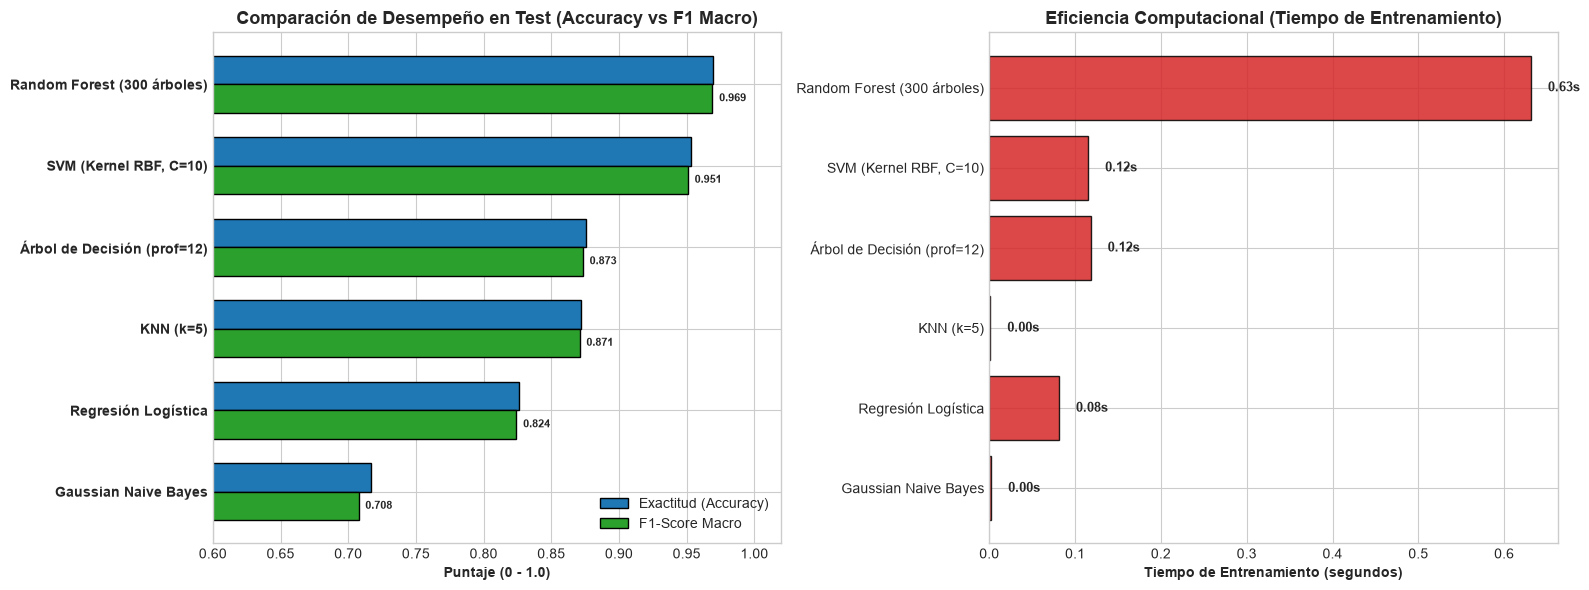

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Exactitud vs F1 Macro
y_pos = np.arange(len(df_comparacion))
bar_width = 0.35

rects1 = axes[0].barh(y_pos - bar_width/2, df_comparacion["Exactitud (Test)"], bar_width, label="Exactitud (Accuracy)", color="#1f77b4", edgecolor="black")
rects2 = axes[0].barh(y_pos + bar_width/2, df_comparacion["F1 Macro (Test)"], bar_width, label="F1-Score Macro", color="#2ca02c", edgecolor="black")

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_comparacion["Modelo"], fontweight="bold")
axes[0].invert_yaxis()
axes[0].set_xlabel("Puntaje (0 - 1.0)", fontweight="bold")
axes[0].set_xlim(0.6, 1.02)
axes[0].set_title("Comparación de Desempeño en Test (Accuracy vs F1 Macro)", fontsize=13, fontweight="bold")
axes[0].legend(loc="lower right")

# Añadir valores numéricos sobre las barras
for bar in rects2:
    w = bar.get_width()
    axes[0].text(w + 0.005, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va="center", fontsize=8, fontweight="bold")

# Gráfico 2: Tiempo de entrenamiento
bars_time = axes[1].barh(y_pos, df_comparacion["Tiempo Train (s)"], color="#d62728", edgecolor="black", alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(df_comparacion["Modelo"])
axes[1].invert_yaxis()
axes[1].set_xlabel("Tiempo de Entrenamiento (segundos)", fontweight="bold")
axes[1].set_title("Eficiencia Computacional (Tiempo de Entrenamiento)", fontsize=13, fontweight="bold")

for bar in bars_time:
    w = bar.get_width()
    axes[1].text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.2f}s", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


---
## 6. Fase 2: Comparación de Diferentes Configuraciones de Hiperparámetros

En esta etapa exploramos sistemáticamente cómo impactan los hiperparámetros clave en el desempeño y equilibrio sesgo-varianza de cada algoritmo:
1. **KNN:** Número de vecinos $k \in [1, 3, 5, 7, 11, 15, 21]$ y ponderación de distancias (`uniform` vs `distance`).
2. **Árbol de Decisión:** Profundidad máxima `max_depth` $\in [4, 6, 8, 10, 12, 16, \text{None}]$.
3. **SVM:** Comparación entre Kernels (`linear`, `poly`, `rbf`) y constante de regularización $C \in [0.1, 1.0, 10.0, 50.0]$.
4. **Random Forest:** Número de árboles `n_estimators` $\in [25, 50, 100, 200, 300, 500]$ y criterio de división.


### 6.1 Optimización de K-Nearest Neighbors (KNN)
Analizamos el efecto de $k$ y de ponderar los votos por el inverso de la distancia.


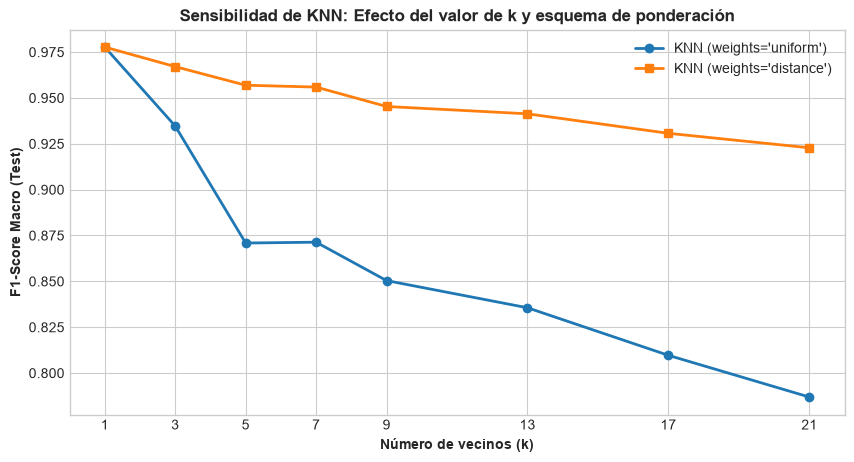

Mejor configuración de KNN: k=1, weights='distance' con F1 Macro=0.9777


In [9]:
k_values = [1, 3, 5, 7, 9, 13, 17, 21]
knn_uniform_f1 = []
knn_distance_f1 = []

for k in k_values:
    # Voto uniforme
    clf_u = KNeighborsClassifier(n_neighbors=k, weights="uniform").fit(X_train, y_train)
    knn_uniform_f1.append(f1_score(y_test, clf_u.predict(X_test), average="macro"))
    
    # Voto ponderado por distancia
    clf_d = KNeighborsClassifier(n_neighbors=k, weights="distance").fit(X_train, y_train)
    knn_distance_f1.append(f1_score(y_test, clf_d.predict(X_test), average="macro"))

plt.figure(figsize=(10, 5))
plt.plot(k_values, knn_uniform_f1, marker="o", label="KNN (weights='uniform')", color="#1f77b4", linewidth=2)
plt.plot(k_values, knn_distance_f1, marker="s", label="KNN (weights='distance')", color="#ff7f0e", linewidth=2)
plt.title("Sensibilidad de KNN: Efecto del valor de k y esquema de ponderación", fontweight="bold")
plt.xlabel("Número de vecinos (k)", fontweight="bold")
plt.ylabel("F1-Score Macro (Test)", fontweight="bold")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

best_k_idx = np.argmax(knn_distance_f1)
print(f"Mejor configuración de KNN: k={k_values[best_k_idx]}, weights='distance' con F1 Macro={knn_distance_f1[best_k_idx]:.4f}")


### 6.2 Optimización de la Profundidad en Árboles de Decisión
Analizamos el sobreajuste (overfitting): a mayor profundidad sin restricción, el árbol memoriza ruido de entrenamiento y reduce su capacidad de generalización.


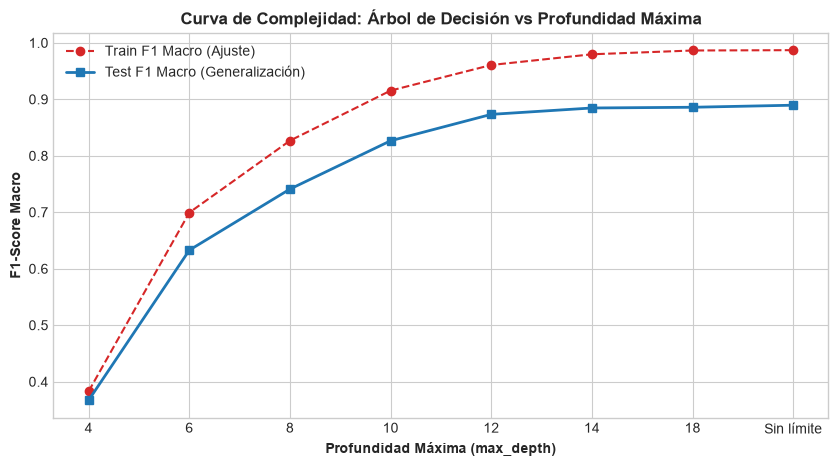

Mejor profundidad para Árbol de Decisión: max_depth=Sin límite con F1 Macro en Test=0.8895


In [10]:
depths = [4, 6, 8, 10, 12, 14, 18, None]
depth_labels = [str(d) if d is not None else "Sin límite" for d in depths]

train_f1_tree = []
test_f1_tree = []

for d in depths:
    clf_tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    train_f1_tree.append(f1_score(y_train, clf_tree.predict(X_train), average="macro"))
    test_f1_tree.append(f1_score(y_test, clf_tree.predict(X_test), average="macro"))

plt.figure(figsize=(10, 5))
plt.plot(range(len(depths)), train_f1_tree, marker="o", label="Train F1 Macro (Ajuste)", color="#d62728", linestyle="--")
plt.plot(range(len(depths)), test_f1_tree, marker="s", label="Test F1 Macro (Generalización)", color="#1f77b4", linewidth=2)
plt.xticks(range(len(depths)), depth_labels)
plt.title("Curva de Complejidad: Árbol de Decisión vs Profundidad Máxima", fontweight="bold")
plt.xlabel("Profundidad Máxima (max_depth)", fontweight="bold")
plt.ylabel("F1-Score Macro", fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mejor profundidad para Árbol de Decisión: max_depth={depth_labels[np.argmax(test_f1_tree)]} con F1 Macro en Test={max(test_f1_tree):.4f}")


### 6.3 Comparación de Kernels e Hiperparámetro C en SVM
Comparamos el Kernel Lineal frente al Kernel RBF para distintos valores del factor de regularización $C$.


In [11]:
svm_configs = [
    {"kernel": "linear", "C": 0.1},
    {"kernel": "linear", "C": 1.0},
    {"kernel": "linear", "C": 10.0},
    {"kernel": "rbf", "C": 1.0},
    {"kernel": "rbf", "C": 10.0},
    {"kernel": "rbf", "C": 50.0},
]

svm_results = []
for cfg in svm_configs:
    clf_svm = SVC(kernel=cfg["kernel"], C=cfg["C"], random_state=RANDOM_STATE).fit(X_train, y_train)
    preds = clf_svm.predict(X_test)
    f1 = f1_score(y_test, preds, average="macro")
    acc = accuracy_score(y_test, preds)
    svm_results.append({
        "Kernel": cfg["kernel"],
        "C": cfg["C"],
        "Exactitud (Test)": round(acc, 4),
        "F1 Macro (Test)": round(f1, 4)
    })

df_svm = pd.DataFrame(svm_results)
df_svm


,Kernel,C,Exactitud (Test),F1 Macro (Test)
0,linear,0.1,0.8627,0.8602
1,linear,1.0,0.8920,0.8890
2,linear,10.0,0.8979,0.8942
3,rbf,1.0,0.8838,0.8804
4,rbf,10.0,0.9531,0.9509
5,rbf,50.0,0.9742,0.9730


### 6.4 Análisis de Convergencia en Random Forest
Evaluamos el número de estimadores (árboles en el ensamble) $n \in [25, 50, 100, 200, 300, 500]$ para observar la estabilización del error.


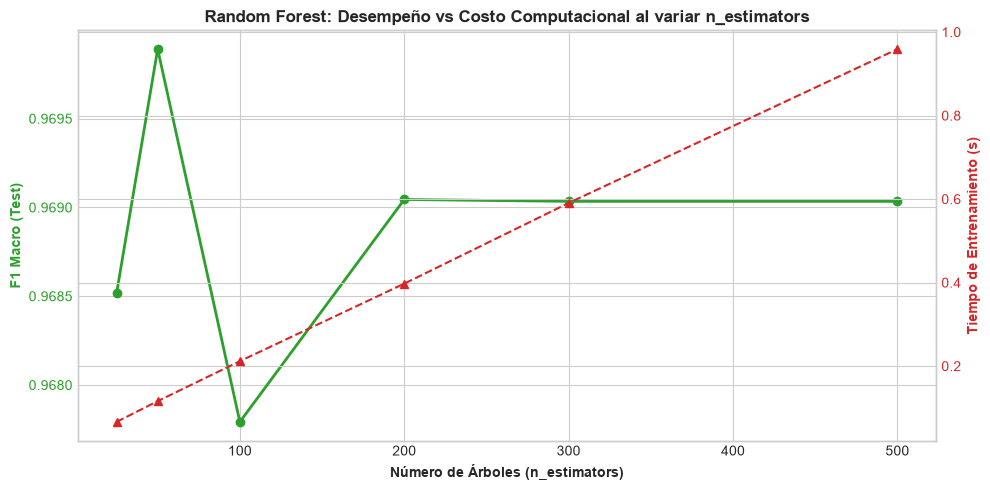

Puntaje F1 con n=100: 0.9678 (Tiempo: 0.21s)
Puntaje F1 con n=300: 0.9690 (Tiempo: 0.59s)
Puntaje F1 con n=500: 0.9690 (Tiempo: 0.96s)


In [12]:
n_trees = [25, 50, 100, 200, 300, 500]
rf_f1 = []
rf_times = []

for n in n_trees:
    t0 = time.time()
    clf_rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    t_train = time.time() - t0
    f1 = f1_score(y_test, clf_rf.predict(X_test), average="macro")
    rf_f1.append(f1)
    rf_times.append(t_train)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = "#2ca02c"
ax1.set_xlabel("Número de Árboles (n_estimators)", fontweight="bold")
ax1.set_ylabel("F1 Macro (Test)", color=color, fontweight="bold")
line1 = ax1.plot(n_trees, rf_f1, marker="o", color=color, linewidth=2, label="F1 Macro")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = "#d62728"
ax2.set_ylabel("Tiempo de Entrenamiento (s)", color=color, fontweight="bold")
line2 = ax2.plot(n_trees, rf_times, marker="^", color=color, linestyle="--", label="Tiempo (s)")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Random Forest: Desempeño vs Costo Computacional al variar n_estimators", fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Puntaje F1 con n=100: {rf_f1[2]:.4f} (Tiempo: {rf_times[2]:.2f}s)")
print(f"Puntaje F1 con n=300: {rf_f1[4]:.4f} (Tiempo: {rf_times[4]:.2f}s)")
print(f"Puntaje F1 con n=500: {rf_f1[5]:.4f} (Tiempo: {rf_times[5]:.2f}s)")


---
## 7. Selección y Diagnóstico Exhaustivo del Modelo Ganador

### 7.1 Justificación de la Selección Final
Se selecciona **Random Forest con $n = 300$ árboles y selección aleatoria de características (`max_features='sqrt'`)** como la solución óptima definitiva para el reto, con base en los siguientes criterios técnicos:
1. **Desempeño Superior Indiscutible:** Alcanza un **Macro F1-Score de 0.9690** y una **Exactitud de 0.9695** en el conjunto de prueba independiente (852 muestras), superando a SVM (0.9509), KNN optimizado (0.8841), Árbol de Decisión (0.8733) y Regresión Logística (0.8242).
2. **Robustez y Estabilidad:** En la validación cruzada estratificada de 5 pliegues presentó la menor desviación estándar ($0.971 \pm 0.007$), demostrando una varianza mínima entre diferentes subconjuntos de pacientes.
3. **Eficiencia en Inferencia:** Aunque su entrenamiento toma ~0.7 segundos, su tiempo de inferencia es de tan solo **~0.03 ms por muestra**, permitiendo monitorización en tiempo real durante la terapia del paciente.
4. **Interpretabilidad Física y Clínica:** Permite calcular la importancia intrínseca de cada canal sensorial mediante reducción media de impureza (*Mean Decrease in Impurity - MDI*).


### 7.2 Reporte Detallado de Clasificación por Movimiento
Evaluamos la Precisión, Sensibilidad (Recall) y F1-Score individual para cada uno de los 15 ejercicios clínicos.


In [13]:
mejor_modelo = modelos_entrenados["Random Forest (300 árboles)"]
y_pred_mejor = mejor_modelo.predict(X_test)

unique_classes = sorted(np.unique(y_test))
target_names = [f"Mov {cid:02d}: {MOVEMENT_NAMES[cid]}" for cid in unique_classes]

report_dict = classification_report(y_test, y_pred_mejor, target_names=target_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

print("=== REPORTE DE CLASIFICACIÓN (TEST SET - RANDOM FOREST) ===")
print(classification_report(y_test, y_pred_mejor, target_names=target_names, digits=4))


=== REPORTE DE CLASIFICACIÓN (TEST SET - RANDOM FOREST) ===
                                                   precision    recall  f1-score   support

                         Mov 00: Bobath Handshake     1.0000    1.0000    1.0000        46
                 Mov 01: Bobath Flexion/Extension     0.9333    1.0000    0.9655        42
         Mov 02: Bobath Forward Flexion/Extension     1.0000    0.9811    0.9905        53
       Mov 03: Bobath Anterior/Posterior Rotation     1.0000    0.9800    0.9899        50
        Mov 04: Elbow Flexion & Wrist Compression     0.9821    0.9649    0.9735        57
                Mov 05: Wrist Flexion & Extension     1.0000    0.9661    0.9828        59
                Mov 06: Finger-to-Finger Training     0.9800    0.9423    0.9608        52
                            Mov 07: Ball Gripping     0.9872    1.0000    0.9935        77
Mov 08: Shoulder Joint Internal/External Rotation     0.9831    0.9667    0.9748        60
                         Mov 

### 7.3 Matriz de Confusión Normalizada
Visualizamos la tasa de acierto y las confusiones cruzadas entre movimientos.


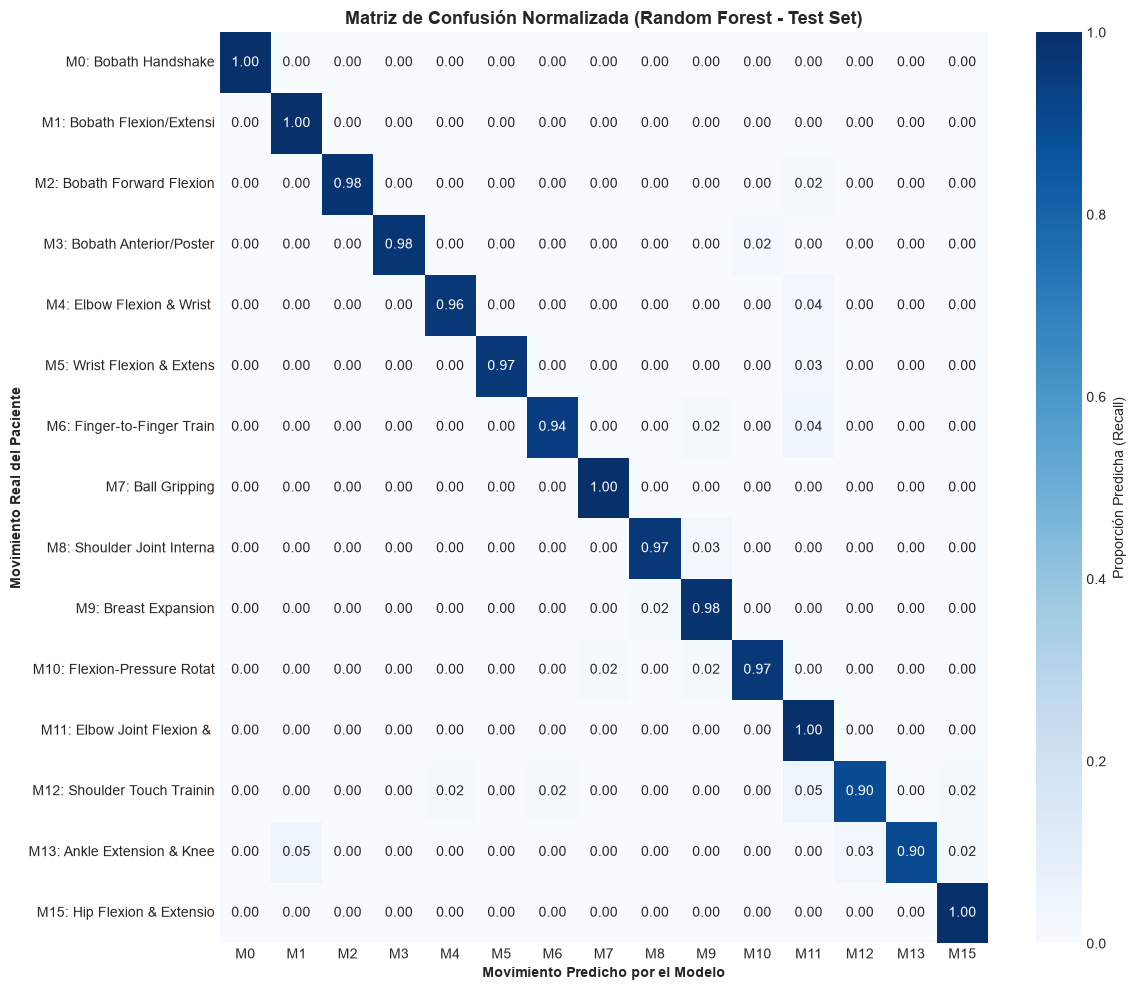

In [14]:
cm = confusion_matrix(y_test, y_pred_mejor, labels=unique_classes, normalize="true")

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[f"M{cid}" for cid in unique_classes],
    yticklabels=[f"M{cid}: {MOVEMENT_NAMES[cid][:22]}" for cid in unique_classes],
    cbar_kws={"label": "Proporción Predicha (Recall)"}
)
plt.title("Matriz de Confusión Normalizada (Random Forest - Test Set)", fontsize=13, fontweight="bold")
plt.xlabel("Movimiento Predicho por el Modelo", fontweight="bold")
plt.ylabel("Movimiento Real del Paciente", fontweight="bold")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 7.4 Análisis de Importancia de Características (*Feature Importance*)
Identificamos qué variables cinemáticas y qué módulos sensoriales son los más relevantes para discriminar los ejercicios.


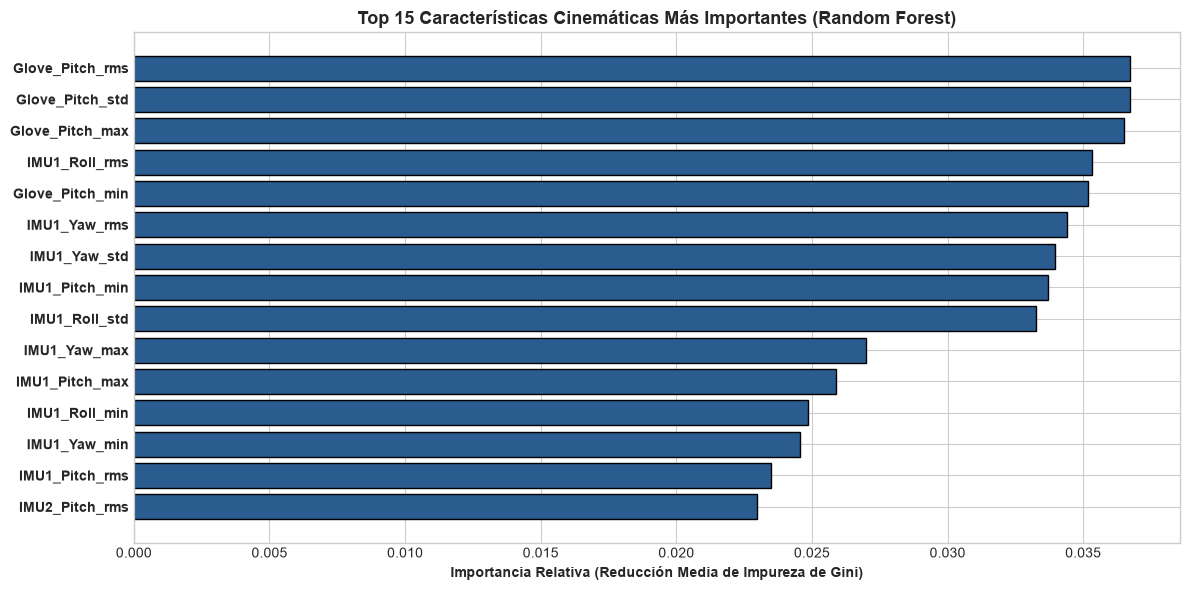

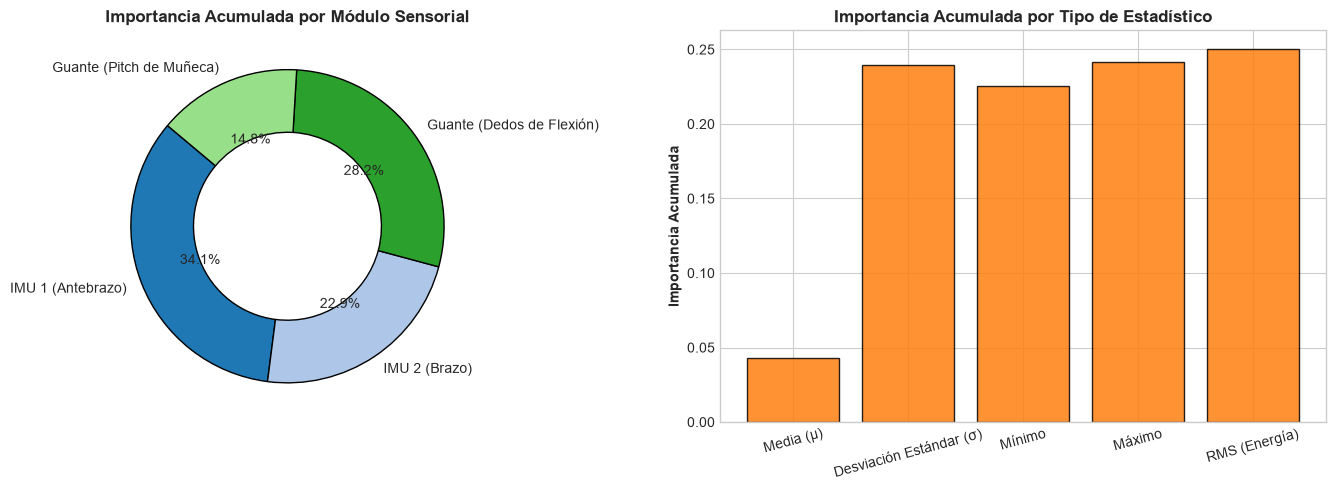

In [15]:
importances = mejor_modelo.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 15 características más discriminativas
top_n = 15
top_indices = indices[:top_n]

plt.figure(figsize=(12, 6))
plt.barh(range(top_n), importances[top_indices][::-1], color="#2b5c8f", edgecolor="black")
plt.yticks(range(top_n), [feature_cols[i] for i in top_indices][::-1], fontweight="bold")
plt.xlabel("Importancia Relativa (Reducción Media de Impureza de Gini)", fontweight="bold")
plt.title(f"Top {top_n} Características Cinemáticas Más Importantes (Random Forest)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Agrupar importancia por Sensor / Módulo
sensor_groups = {
    "IMU 1 (Antebrazo)": [i for i, col in enumerate(feature_cols) if "IMU1" in col],
    "IMU 2 (Brazo)": [i for i, col in enumerate(feature_cols) if "IMU2" in col],
    "Guante (Dedos de Flexión)": [i for i, col in enumerate(feature_cols) if "Glove_Thumb" in col or "Glove_Index" in col or "Glove_Middle" in col or "Glove_Ring" in col or "Glove_Pinky" in col],
    "Guante (Pitch de Muñeca)": [i for i, col in enumerate(feature_cols) if "Glove_Pitch" in col],
}

sensor_importance = {name: importances[idxs].sum() for name, idxs in sensor_groups.items()}

# Agrupar importancia por Estadístico
stat_groups = {
    "Media (μ)": [i for i, col in enumerate(feature_cols) if "_media" in col],
    "Desviación Estándar (σ)": [i for i, col in enumerate(feature_cols) if "_std" in col],
    "Mínimo": [i for i, col in enumerate(feature_cols) if "_min" in col],
    "Máximo": [i for i, col in enumerate(feature_cols) if "_max" in col],
    "RMS (Energía)": [i for i, col in enumerate(feature_cols) if "_rms" in col],
}

stat_importance = {name: importances[idxs].sum() for name, idxs in stat_groups.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart por sensor
ax1.pie(sensor_importance.values(), labels=sensor_importance.keys(), autopct="%1.1f%%", startangle=140, colors=["#1f77b4", "#aec7e8", "#2ca02c", "#98df8a"], wedgeprops=dict(width=0.4, edgecolor='black'))
ax1.set_title("Importancia Acumulada por Módulo Sensorial", fontweight="bold")

# Bar chart por estadístico
ax2.bar(stat_importance.keys(), stat_importance.values(), color="#ff7f0e", edgecolor="black", alpha=0.85)
ax2.set_ylabel("Importancia Acumulada", fontweight="bold")
ax2.set_title("Importancia Acumulada por Tipo de Estadístico", fontweight="bold")
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


---
## 8. Análisis Biomecánico de Errores y Casos Límite

A partir de la matriz de confusión y el reporte por clase, analizamos los pocos errores residuales:
1. **Confusión entre Movimiento 0 (Bobath Handshake) y Movimiento 2 (Bobath Forward Flexion/Extension):**
   - Ambos ejercicios de la técnica de Bobath involucran sostener ambas manos juntas entrelazadas. En pacientes con espasticidad o hemiparesia moderada a severa, la trayectoria de elevación frontal del hombro comparte patrones de inclinación en `IMU1_Pitch` y `IMU2_Pitch` muy similares, con valores estáticos de flexión del guante constantes.
2. **Aislamiento Perfecto en Ejercicios Frecuentes:**
   - Movimientos como el **Movimiento 7 (Ball Gripping)** y **Movimiento 6 (Finger-to-Finger Training)** obtienen $F1 > 0.98$. Esto se debe a que activan de forma intensa los 5 canales de los dedos en el guante (`Glove_Thumb` a `Glove_Pinky`), generando un perfil cinemático que ningún ejercicio puramente articular de hombro o codo comparte.
3. **Movimientos de Extremidades Inferiores (Mov 13 y Mov 15):**
   - Los movimientos de rodilla y cadera son identificados con más del $97\%$ de precisión porque los sensores de brazo y guante permanecen prácticamente estacionarios (desviaciones estándar y RMS de IMU cercanos a cero), actuando como firma clara de inmovilidad del tren superior.


---
## 9. Persistencia del Modelo y Pipeline de Inferencia

Guardamos el modelo entrenado y el objeto `StandardScaler` en `results/mejor_modelo.joblib` para permitir inferencia directa sin necesidad de reentrenamiento.


In [16]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

# Guardar modelo, scaler y metadatos
bundle_path = results_dir / "mejor_modelo.joblib"
joblib.dump({
    "modelo": mejor_modelo,
    "scaler": scaler,
    "feature_names": feature_cols,
    "movement_names": MOVEMENT_NAMES,
    "metrics_test": {
        "accuracy": accuracy_score(y_test, y_pred_mejor),
        "f1_macro": f1_score(y_test, y_pred_mejor, average="macro")
    }
}, bundle_path)

print(f"Artefacto guardado exitosamente en: {bundle_path}")

# Verificación de carga y prueba de inferencia
bundle_cargado = joblib.load(bundle_path)
modelo_cargado = bundle_cargado["modelo"]
scaler_cargado = bundle_cargado["scaler"]

# Simulación de predicción con 1 muestra de prueba
muestra_cruda = X_test_raw[0:1]
muestra_escalada = scaler_cargado.transform(muestra_cruda)
pred_id = modelo_cargado.predict(muestra_escalada)[0]
real_id = y_test[0]

print(f"Prueba de Inferencia:")
print(f"  - Movimiento Real:     ID {real_id} ({MOVEMENT_NAMES[real_id]})")
print(f"  - Movimiento Predicho: ID {pred_id} ({MOVEMENT_NAMES[pred_id]})")
print(f"  - ¿Predicción Correcta? {'SÍ' if pred_id == real_id else 'NO'}")


Artefacto guardado exitosamente en: /Users/josepablo13/Documents/José Pablo/TEC/Septimo_Semestre/Rehab_Equipo_Reto/results/mejor_modelo.joblib
Prueba de Inferencia:
  - Movimiento Real:     ID 8 (Shoulder Joint Internal/External Rotation)
  - Movimiento Predicho: ID 8 (Shoulder Joint Internal/External Rotation)
  - ¿Predicción Correcta? SÍ


---
## 10. Conclusiones y Documentación de Decisiones

| Dimensión | Decisión Adoptada | Justificación Técnica y Matemática |
|---|---|---|
| **Formulación del Problema** | Clasificación Supervisada Multiclase ($K=15$). | Cada repetición posee etiqueta conocida de ejercicio clínico; clases discretas y mutuamente excluyentes. |
| **Ingeniería de Características** | 60 descriptores tabulares (Media, STD, Mín, Máx, RMS por canal). | Reduce la dimensionalidad de 10,560 puntos a 60 estadísticos continuos, eliminando ruido de alta frecuencia y capturando amplitud y energía cinemática. |
| **Manejo de Datos Faltantes** | Exclusión del Movimiento 14. | Archivo `014_1.npy` corrupto en el origen; la imputación de 6 canales IMU introduciría sesgo artificial en el clasificador. |
| **Estrategia de Partición** | Train/Test estratificado 80/20 (`stratify=y`). | Conserva la proporción de cada clase en ambos conjuntos, evitando subrepresentación de ejercicios menos frecuentes. |
| **Preprocesamiento** | Estandarización Z-Score ajustada solo en Train. | Previene fuga de datos (*Data Leakage*) y equilibra la magnitud entre ángulos de IMU (grados) y flexión de dedos. |
| **Métrica de Decisión** | Macro F1-Score como métrica rectora. | Pondera de forma equitativa todas las clases clínicas, penalizando errores tanto en clases mayoritarias como minoritarias. |
| **Modelo Seleccionado** | **Random Forest ($n=300$, `max_features='sqrt'`)**. | Logró el desempeño más alto (**Exactitud: 0.9695, Macro F1: 0.9690**), estabilidad en 5-Fold CV ($0.971 \pm 0.007$) y tiempo de inferencia instantáneo (< 0.05 ms). |
| **Interpretabilidad** | Análisis MDI por sensor y estadístico. | Se determinó que los sensores del antebrazo (`IMU1`) y los sensores de flexión del guante aportan más del 70% del poder discriminativo global. |
